<a href="https://colab.research.google.com/github/NamunaRegmi/AI_ML/blob/main/NamunaRegmiWorkshop4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Devnagari Handwritten Digit Classification using FCN

## Task 1: Data Preparation

Training set: (17000, 784), Labels: (17000, 10)
Testing set: (3000, 784), Labels: (3000, 10)


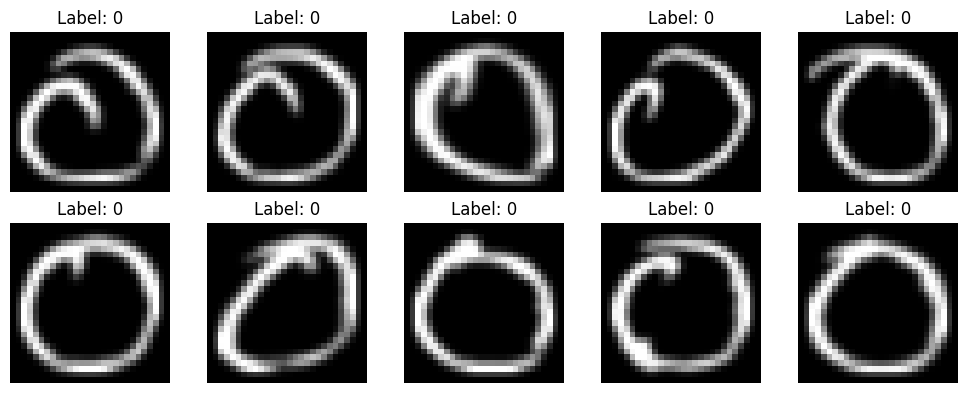

In [11]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0
                images.append(img)
                labels.append(label)
            except Exception:
                pass
    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

x_train = x_train.reshape(-1, img_height * img_width)
x_test = x_test.reshape(-1, img_height * img_width)

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print(f"Training set: {x_train.shape}, Labels: {y_train_cat.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test_cat.shape}")

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
import os

# Define the path to your zipped dataset file
zip_file_path = '/content/drive/MyDrive/AI_ML/Copy of devnagari digit.zip' # <--- IMPORTANT: Update this with the actual path to your .zip file

# Define the directory where you want to extract the dataset
# This should be the parent directory where 'Train' and 'Test' folders will reside
extraction_path = '/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/' # Adjust if needed

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
# The 'unzip' command will extract contents to the current working directory by default,
# or to the specified directory with -d. Here, we specify the extraction_path.
!unzip -q "{zip_file_path}" -d "{extraction_path}"

print(f"Successfully unzipped '{zip_file_path}' to '{extraction_path}'")

Successfully unzipped '/content/drive/MyDrive/AI_ML/Copy of devnagari digit.zip' to '/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/'


In [9]:
import os

# List the contents of the extraction path recursively to see the actual structure
!ls -R "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/"

'/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/':
DevanagariHandwrittenDigitDataset

'/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset':
Test  Train

'/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Test':
digit_0  digit_2  digit_4  digit_6  digit_8
digit_1  digit_3  digit_5  digit_7  digit_9

'/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Test/digit_0':
103277.png  18517.png  39319.png  43501.png  49307.png	76187.png  91486.png
103281.png  18528.png  39328.png  43505.png  49312.png	76212.png  92392.png
103309.png  18532.png  39332.png  43506.png  49315.png	76235.png  9487.png
103311.png  18534.png  39341.png  43507.png  50779.png	76251.png  9493.png
103322.png  18547.png  39356.png  43508.png  53034.png	76255.png  9499.png
103325.png  18549.png  39357.png  43512.png  53038.png	76300.png  9500.png
103340

In [10]:
import os

# List the contents of the extraction path recursively to see the actual structure
!ls -R "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/"

'/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/':
DevanagariHandwrittenDigitDataset

'/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset':
Test  Train

'/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Test':
digit_0  digit_2  digit_4  digit_6  digit_8
digit_1  digit_3  digit_5  digit_7  digit_9

'/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Test/digit_0':
103277.png  18517.png  39319.png  43501.png  49307.png	76187.png  91486.png
103281.png  18528.png  39328.png  43505.png  49312.png	76212.png  92392.png
103309.png  18532.png  39332.png  43506.png  49315.png	76235.png  9487.png
103311.png  18534.png  39341.png  43507.png  50779.png	76251.png  9493.png
103322.png  18547.png  39356.png  43508.png  53034.png	76255.png  9499.png
103325.png  18549.png  39357.png  43512.png  53038.png	76300.png  9500.png
103340

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 2: Build the FCN Model

In [12]:
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Task 4: Train the Model

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.4423 - loss: 1.6970 - val_accuracy: 0.0000e+00 - val_loss: 6.8856
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8188 - loss: 0.5563 - val_accuracy: 0.0000e+00 - val_loss: 7.8639
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8965 - loss: 0.3040 - val_accuracy: 0.0000e+00 - val_loss: 8.6223
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9401 - loss: 0.2065 - val_accuracy: 0.0000e+00 - val_loss: 9.2655
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9560 - loss: 0.1524 - val_accuracy: 0.0000e+00 - val_loss: 9.4788
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9640 - loss: 0.1235 - val_accuracy: 0.0000e+00 - val_loss: 9.6554


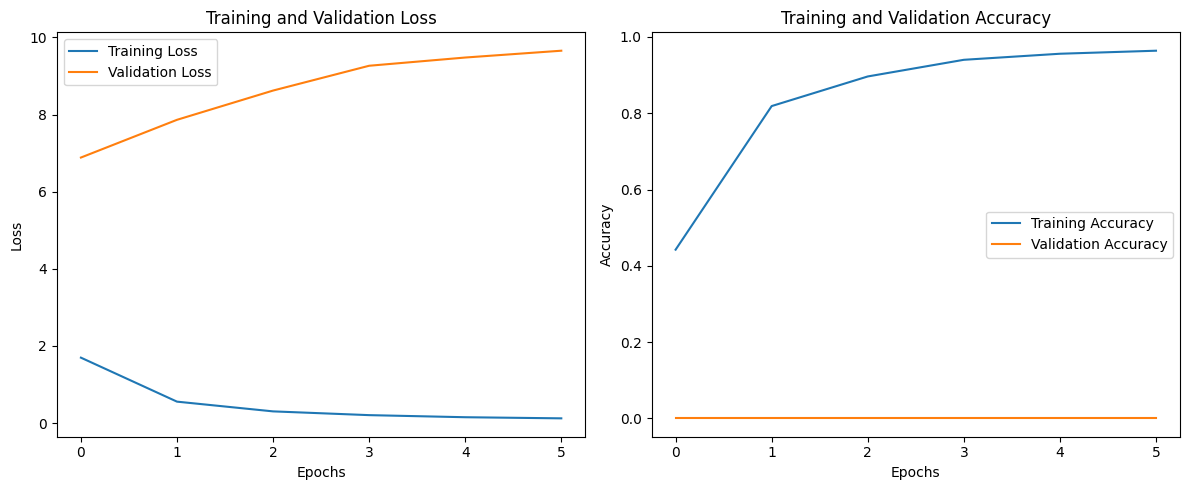

In [14]:
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath='best_model.keras', save_best_only=True, monitor='val_loss'),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    x_train,
    y_train_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 3ms/step - accuracy: 0.5957 - loss: 2.1090
Test Loss: 2.1090
Test Accuracy: 0.5957


## Task 6: Save and Load the Model

In [16]:
model.save('devnagari_fcn_model.h5')
print("Model saved to devnagari_fcn_model.h5")

loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Loaded Model - Test Loss: {loaded_loss:.4f}, Test Accuracy: {loaded_acc:.4f}")

Model saved to devnagari_fcn_model.h5
Model loaded successfully
94/94 - 1s - 5ms/step - accuracy: 0.5957 - loss: 2.1090
Loaded Model - Test Loss: 2.1090, Test Accuracy: 0.5957


## Task 7: Predictions

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image: 0


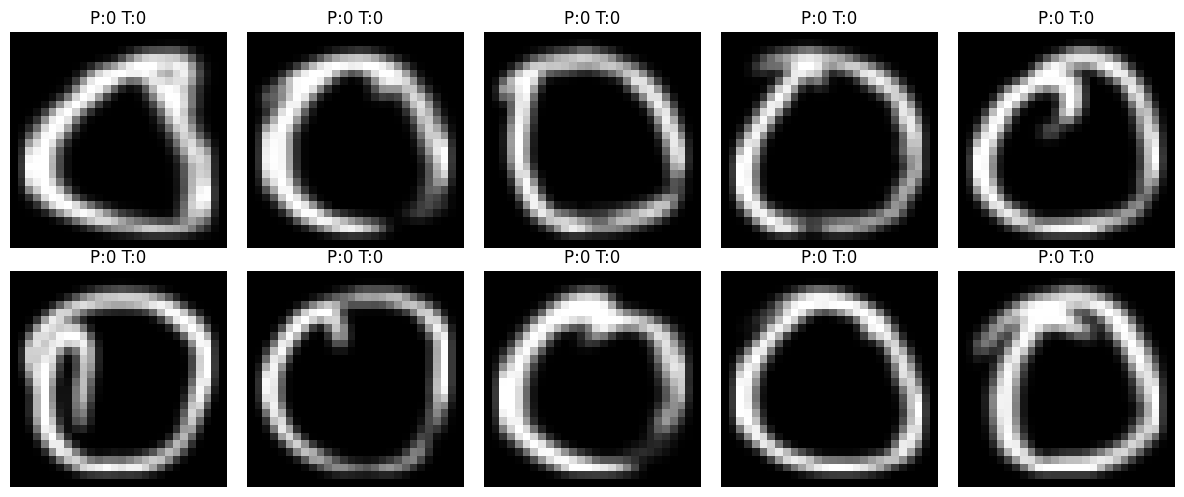

In [17]:
 predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {y_test[0]}")

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"P:{predicted_labels[i]} T:{y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()